In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylie import SE3, SO3, R3, SE23
from ins_observer import ComplementaryINS

In [2]:
def get_from_df(df, column_prefix, dims, step):
    # odom
    #   pose (x,y,z)
    #   orientation (x,y,z,w)
    #   twist
    #       linear velocity (x,y,z)
    #       angular velocity (x,y,z)
    # imu
    #   linear (x,y,z)
    #   angular (x,y,z)
    #   orientation (x,y,z,w)
    return df.iloc[step][[f"{column_prefix}_{d}" for d in dims]]


sim_speed_multiplier = 25
dt = 0.001 * sim_speed_multiplier
df = pd.read_csv("combined_data_with_velocity.csv")
# df = pd.read_csv("combined_data.csv")
df = df.iloc[::sim_speed_multiplier].reset_index(drop=True)
time_lim = len(df)

In [3]:
def rpy_from_quat(quat):
    rpys = []
    for q in quat:
        rpy = SO3.from_list(q, format_spec="q").as_euler(
            seq="xyz", degrees=False
        )
        rpys.append(rpy)
    return np.asarray(rpys)


def rotations_from_quat(quat):
    rpys = []
    for q in quat:
        rpy = SO3.from_list(q, format_spec="q").as_matrix()
        rpys.append(rpy)
    return np.asarray(rpys)


quat = get_from_df(
    df, "odom_orientation", ["x", "y", "z", "w"], slice(time_lim)
)
robot_2_global = rotations_from_quat(quat.to_numpy())
vel_robot_frame = get_from_df(
    df, "cmd_vel_linear", ["x", "y", "z"], slice(time_lim)
).to_numpy()
vel_global = np.einsum("bij,bj->bi", robot_2_global, vel_robot_frame)


df["odom_vel_x"] = vel_global[:, 0]
df["odom_vel_y"] = vel_global[:, 1]
df["odom_vel_z"] = vel_global[:, 2]

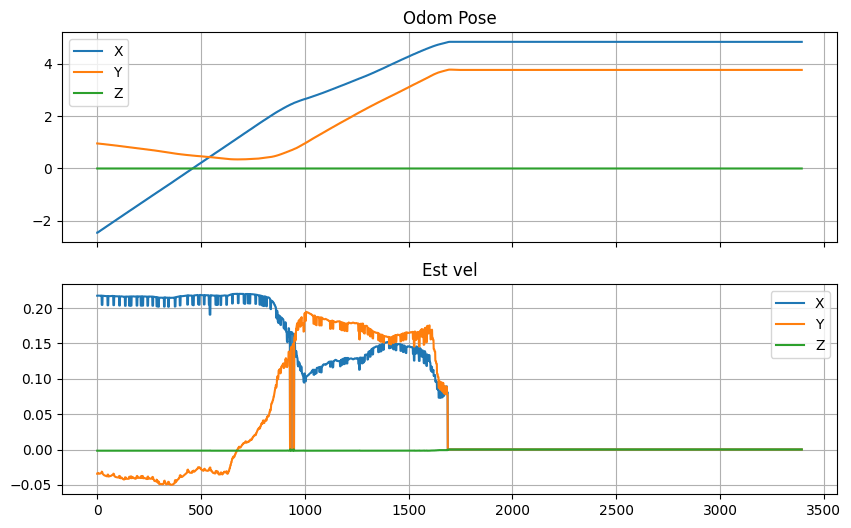

In [5]:
plt.close("all")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(df["odom_pose_x"], label="X")
axes[0].plot(df["odom_pose_y"], label="Y")
axes[0].plot(df["odom_pose_z"], label="Z")
axes[0].set_title("Odom Pose")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    df["odom_vel_x"],
    label="X",
)
axes[1].plot(df["odom_vel_y"], label="Y")
axes[1].plot(df["odom_vel_z"], label="Z")
axes[1].set_title("Est vel")
axes[1].legend()
axes[1].grid(True)

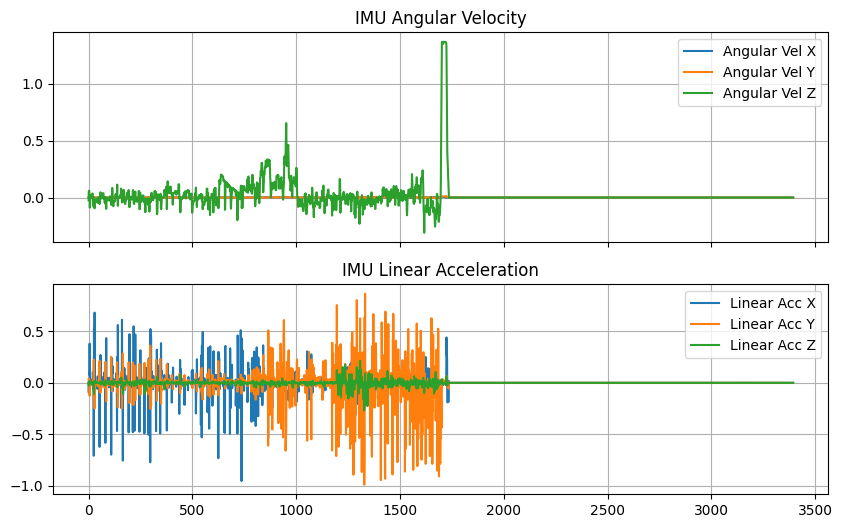

In [6]:
plt.close("all")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(df["imu_angular_vel_x"], label="Angular Vel X")
axes[0].plot(df["imu_angular_vel_y"], label="Angular Vel Y")
axes[0].plot(df["imu_angular_vel_z"], label="Angular Vel Z")
axes[0].set_title("IMU Angular Velocity")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df["imu_linear_acc_x"], label="Linear Acc X")
axes[1].plot(df["imu_linear_acc_y"], label="Linear Acc Y")
axes[1].plot(df["imu_linear_acc_z"], label="Linear Acc Z")
axes[1].set_title("IMU Linear Acceleration")
axes[1].legend()
axes[1].grid(True)